# Trained pipeline

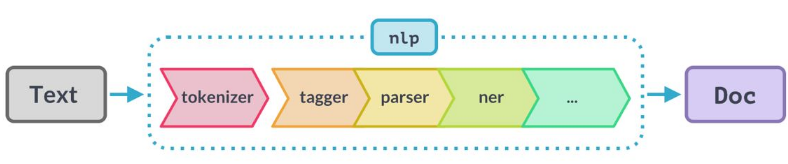

In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [23]:
nlp = spacy.load("en_core_web_sm")
nlp.pipe_names

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [8]:
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")
for token in doc:
  print(token, "|", token.pos_, "|", token.lemma_)

Apple | PROPN | Apple
is | AUX | be
looking | VERB | look
at | ADP | at
buying | VERB | buy
U.K. | PROPN | U.K.
startup | VERB | startup
for | ADP | for
$ | SYM | $
1 | NUM | 1
billion | NUM | billion


In [9]:
for ent in doc.ents:
  print(ent.text, "|", ent.label_, "|", spacy.explain(ent.label_))

Apple | ORG | Companies, agencies, institutions, etc.
U.K. | GPE | Countries, cities, states
$1 billion | MONEY | Monetary values, including unit


In [10]:
from spacy import displacy
displacy.render(doc, style="ent")

In [30]:
# Extracting only proper nouns from text
text = ''' Ravi and Raju are the best friends from school days.They wanted to go for a world tour and
visit famous cities like Paris, London, Dubai, Rome etc and also they called their another friend Mohan to take part of this world tour.
They started their journey from Hyderabad and spent next 3 months travelling all the wonderful cities in the world and cherish a happy moments!
'''
doc = nlp(text)

proper_nouns = []
for token in doc:
  if token.pos_ == "PROPN":
    proper_nouns.append(token.text)

print(proper_nouns)
print(len(proper_nouns))


['Ravi', 'Raju', 'Paris', 'London', 'Dubai', 'Rome', 'Mohan', 'Hyderabad']
8


In [31]:
# Extracting company names from text
text = '''The Top 5 companies in USA are Tesla, Walmart, Amazon, Microsoft, Google and the top 5 companies in
India are Infosys, Reliance, HDFC Bank, Hindustan Unilever and Bharti Airtel'''
doc = nlp(text)

company_names = []
for ent in doc.ents:
  if ent.label_ == "ORG":
    company_names.append(ent.text)

print(company_names)
print(len(company_names))

['Tesla', 'Walmart', 'Amazon', 'Microsoft', 'Google', 'Infosys', 'Reliance', 'HDFC Bank', 'Hindustan Unilever', 'Bharti Airtel']
10


# Blank pipeline

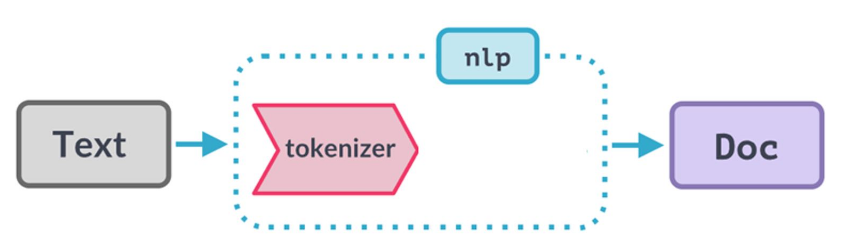

In [20]:
import spacy
nlp = spacy.blank("en")
nlp.pipe_names

[]

In [21]:
# Adding ner component to blank pipeline
source_nlp = spacy.load("en_core_web_sm")
ner = nlp.add_pipe("ner", source=source_nlp)
nlp.pipe_names

['ner']

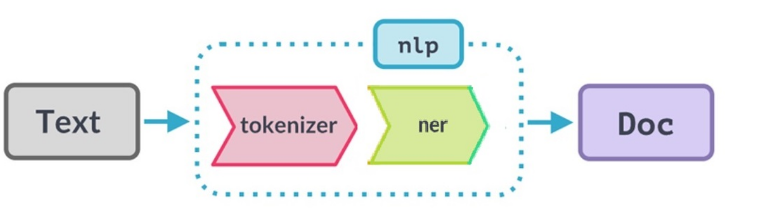

In [22]:
doc = nlp("Apple is looking at buying U.K. startup for $1 billion")
for ent in doc.ents:
  print(ent.text, "|", ent.label_, "|", spacy.explain(ent.label_))

Apple | ORG | Companies, agencies, institutions, etc.
U.K. | GPE | Countries, cities, states
$1 billion | MONEY | Monetary values, including unit


# Trained pipeline in French

In [12]:
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 40.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [13]:
nlp = spacy.load("fr_core_news_sm")
nlp.pipe_names

['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [14]:
doc = nlp("Tesla Inc va racheter Twitter pour $45 milliards de dollars")
for token in doc:
  print(token, "|", token.pos_, "|", token.lemma_)

Tesla | PROPN | Tesla
Inc | PROPN | Inc
va | VERB | aller
racheter | VERB | racheter
Twitter | VERB | twitter
pour | ADP | pour
$ | NOUN | dollar
45 | NUM | 45
milliards | NOUN | milliard
de | ADP | de
dollars | NOUN | dollar


In [15]:
for ent in doc.ents:
    print(ent.text, " | ", ent.label_, " | ", spacy.explain(ent.label_))

Tesla Inc  |  PER  |  Named person or family.
Twitter  |  MISC  |  Miscellaneous entities, e.g. events, nationalities, products or works of art
